In [46]:
import os
import sys
import json
import re

import numpy as np
import pandas as pd
from collections import defaultdict

import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize

In [47]:
# Parent directory PATH
sys.path.append("..")

from utils.json import load_json, save_json

In [48]:
def json_structure(data, max_depth=5, current_depth=0, path="root"):
    """
    Recursively explore and print the structure of JSON data up to a specified depth
    
    Parameters:
        data: The JSON data to explore
        max_depth: Maximum depth to explore
        current_depth: Current depth in the recursion

    Args:
        data: The JSON data to explore
        max_depth: Maximum depth to explore
        current_depth: Current depth in the recursion
        path: Current path in the JSON structure
    """
    
    # Indentation for visualizing depth
    indent = (4*" ") * current_depth
    
    if current_depth >= max_depth:
        print(f"{indent}[Reached max depth at {path}]")
        return
    
    # Handle dictionary
    if isinstance(data, dict):
        print(f"{indent}{path} (dict with {len(data)} keys)")
        for key, value in data.items():
            new_path = f"{path}.{key}" if path != "root" else key
            json_structure(value, max_depth, current_depth + 1, new_path)
    
    # Handle list
    elif isinstance(data, list):
        print(f"{indent}{path} (list with {len(data)} items)")
        if data and current_depth < max_depth - 1:
            # Show structure of first item as an example
            sample_item = data[0]
            new_path = f"{path}[0]"
            json_structure(sample_item, max_depth, current_depth + 1, new_path)
            
            # If there are multiple different structures in the list, show another example
            if len(data) > 1 and not all(type(item) == type(sample_item) for item in data):
                different_type_item = next((item for item in data if type(item) != type(sample_item)), None)
                if different_type_item:
                    new_path = f"{path}[different_type]"
                    json_structure(different_type_item, max_depth, current_depth + 1, new_path)

    # Handle other types
    elif isinstance(data, (str, int, float, bool, type(None))):
        # For primitive types, show a sample value
        if isinstance(data, str) and len(data) > 30:
            sample_value = f"{data[:30]}..." 
        else:
            sample_value = data
        print(f"{indent}{path} ({type(data).__name__}): {sample_value}")

In [49]:
def json_keys(data):
    """
    Extract the key structural components of the dataset
    
    Parameters:
        data (list): The JSON data to explore

    Returns:
        dict: Dictionary containing the structural information
    """
    structure = {
        "main_keys": set(),
        "data_keys": set(),
        "prediction_keys": set(),
        "result_keys": set(),
        "value_keys": set(),
        "label_types": set()
    }
    
    # Process documents to extract generic structure
    for doc in data[:15]:
        # Main level keys
        for key in doc.keys():
            structure["main_keys"].add(key)
        
        # Data level keys
        if "data" in doc:
            for key in doc["data"].keys():
                structure["data_keys"].add(key)
        
        # Prediction level
        if "predictions" in doc and doc["predictions"]:
            for pred in doc["predictions"]:
                for key in pred.keys():
                    structure["prediction_keys"].add(key)
                
                # Result level
                if "result" in pred:
                    for res in pred["result"]:
                        for key in res.keys():
                            structure["result_keys"].add(key)
                        
                        # Value level and labels
                        if "value" in res:
                            for key in res["value"].keys():
                                structure["value_keys"].add(key)
                            
                            # Collect label types
                            if "labels" in res["value"]:
                                for label in res["value"]["labels"]:
                                    structure["label_types"].add(label)
    
    # Convert sets to sorted lists for nicer output
    for key in structure:
        structure[key] = sorted(list(structure[key]))
    
    return structure

In [50]:
def extract_annotations(data):
    """
    Extract all annotations/predictions from the documents to a Dataframe
    
    Parameters:
        data (list): List of document JSON objects

    Returns:
        pd.DataFrame: DataFrame containing all annotations
    """

    # Dataframe new rows
    rows = [] 
    
    # Iterate through all documents
    for doc_index, doc, in enumerate(data):
        doc_id = doc["data"]["id"]
        text = doc["data"]["text"]

        # Empty row for non predicted 
        if "predictions" not in doc or not doc["predictions"]:
            row = {
                "doc_index": doc_index, # Represent the position of each document in your data array
                "doc_id": doc_id,
                "result_id": None,  # No result ID since there are no predictions
                "start": None,      # No start position
                "end": None,        # No end position
                "label": "No Prediction",  # Special label to indicate absence
                "text": None,       # No specific text segment
                "context": text[:50] + "..." if len(text) > 50 else text  # First 50 chars for context
            }
            rows.append(row)
            continue 
        
        # Process predictions
        for pred_index, pred in enumerate(doc["predictions"]):
            if "result" in pred:
                for res_index, res in enumerate(pred["result"]):
                    if "value" in res and "labels" in res["value"]:
                        start = res["value"]["start"]
                        end = res["value"]["end"]
                        
                        # Extract the labeled text segment
                        segment_text = text[start:end]
                        
                        # Create a row for each label
                        for label in res["value"]["labels"]:
                            row = {
                                "doc_index": doc_index,
                                "doc_id": doc_id,
                                "result_id": res["id"],
                                "start": start,
                                "end": end,
                                "label": label,
                                "text":segment_text,
                            }
                            rows.append(row)

                        # Sort rows by start position
                        rows = sorted(rows, key=lambda x: x["start"])
                        rows = sorted(rows, key=lambda x: x["doc_index"])
    
    return pd.DataFrame(rows)

In [179]:
import re

def get_punctuation_stops(text: str) -> list[int]:
    indices = []
    regex = r'\.(?!\d\w)'  # Match dots not followed by digits
    for match in re.finditer(regex, text):
        index = match.start()

        if text[index-3: index] == " dr":
            pass
        elif text[index-3: index] == "(dr":
            pass
        elif text[index-3: index] == "dra":
            pass
        elif text[index-4: index] == "(dra":
            pass
        elif text[index-2: index] == "..":
            pass
        elif text[index-1: index] == ".":
            pass
        elif text[index+2] == ".":
            pass
        elif text[index-1] == " ":
            pass
        else:
            indices.append(index)

    return indices

def extract_documents(data):
    """
    Extract all documents to a DataFrame
    """

    for doc_index, doc in enumerate(data):
        # save to txt
        with open(f"../data/documents/{doc['data']['id']}.txt", "w") as f:
            text = doc["data"]["text"].strip()
            stops = get_punctuation_stops(text)

            start = 0
            for stop in stops:
                part = text[start:stop + 1].strip()  # Include the dot
                if part:
                    f.write(part + "\n")
                start = stop + 1

            # Handle the remaining text after the last stop
            remaining = text[start:].strip()
            if remaining:
                f.write(remaining)
                f.write("\n")

In [52]:
# Load the training data
file = "training.json"
path = "../data/raw/"
data = load_json(os.path.join(path, file))

In [53]:
print(f"Type of loaded data: {type(data)}")
print(f"Number of documents: {len(data)}")

Type of loaded data: <class 'list'>
Number of documents: 254


In [158]:
# Explore your JSON data
json_structure(data, max_depth=10)

root (list with 254 items)
    root[0] (dict with 3 keys)
        root[0].data (dict with 6 keys)
            root[0].data.cmbd (str): null
            root[0].data.id (str): 19026587
            root[0].data.docid (str): null
            root[0].data.page (str): null
            root[0].data.paragraph (str): null
            root[0].data.text (str):  nº historia clinica: ** *** *...
        root[0].annotations (list with 0 items)
        root[0].predictions (list with 1 items)
            root[0].predictions[0] (dict with 1 keys)
                root[0].predictions[0].result (list with 20 items)
                    root[0].predictions[0].result[0] (dict with 5 keys)
                        root[0].predictions[0].result[0].value (dict with 3 keys)
                            root[0].predictions[0].result[0].value.start (int): 449
                            root[0].predictions[0].result[0].value.end (int): 452
                            root[0].predictions[0].result[0].value.labels (l

In [159]:
# Get the JSON keys structure
structure = json_keys(data)

display(structure)

{'main_keys': ['annotations', 'data', 'predictions'],
 'data_keys': ['cmbd', 'docid', 'id', 'page', 'paragraph', 'text'],
 'prediction_keys': ['result'],
 'result_keys': ['from_name', 'id', 'to_name', 'type', 'value'],
 'value_keys': ['end', 'labels', 'start'],
 'label_types': ['NEG', 'NSCO', 'UNC', 'USCO']}

In [160]:
# Insights using the first document
record_first = data[0]

if isinstance(data, list):
    print(f"Type document: {type(data[0])}")
    print(f"Keys document: {structure['main_keys']}")
    print()

    for main_keys in record_first:
        print(f"Key: {main_keys}")
        print(f"Type: {type(record_first[main_keys])}")
        print(f"Length: {len(record_first[main_keys])}")
        print(f"Value: {record_first[main_keys]}")
        print()

        if "data" in main_keys:
            for k in record_first["data"].keys():
                print(f"\tKey: {k}")
                print(f"\tType: {type(record_first['data'][k])}")
                print(f"\tLength: {len(record_first['data'][k])}")
                print(f"\tValue: {record_first['data'][k]}")
                print()

Type document: <class 'dict'>
Keys document: ['annotations', 'data', 'predictions']

Key: data
Type: <class 'dict'>
Length: 6
Value: {'cmbd': 'null', 'id': '19026587', 'docid': 'null', 'page': 'null', 'paragraph': 'null', 'text': " nº historia clinica: ** *** *** nºepisodi: ******** sexe: home data de naixement: 16.05.1936 edat: 82 anys procedencia cex mateix hosp servei urologia data d'ingres 24.07.2018 data d'alta 25.07.2018 08:54:04 ates per ***************, *****; ****************, ****** informe d'alta d'hospitalitzacio motiu d'ingres paciente que ingresa de forma programada para realizacion de uretrotomia interna . antecedents alergia a penicilina y cloramfenicol . no habitos toxicos. antecedentes medicos: bloqueo auriculoventricular de primer grado hipertension arterial. diverticulosis extensa insuficiencia renal cronica colelitiasis antecedentes quirurgicos: exeresis de lesiones cutaneas con anestesia local protesis total de cadera cordectomia herniorrafia inguinal proces actua

In [180]:
extract_documents(data)

In [58]:
# Extract all annotations
df_predictions = extract_annotations(data)

print(f"Extracted {len(df_predictions)} annotations")
display(df_predictions)

Extracted 9319 annotations


,doc_index,doc_id,result_id,start,end,label,text
0,0,19026587,ent0,449,452,NEG,no
1,0,19026587,ent1,452,468,NSCO,habitos toxicos.
2,0,19026587,ent2,844,856,NSCO,cistoscopia
3,0,19026587,ent3,863,872,NEG,negativa
4,0,19026587,ent4,872,895,NSCO,para lesiones malignas
...,...,...,...,...,...,...,...
9314,253,20339886,ent23,3765,3788,NSCO,el hemocultivo cursado
9315,253,20339886,ent44,3796,3804,NEG,negativo
9316,253,20339886,ent24,3856,3864,NEG,afebril
9317,253,20339886,ent25,4147,4159,UNC,sospecha de


In [ ]:
import string

def remove_punctuation(tokens):
    return [token for token in tokens if token not in string.punctuation]

def remove_punctuation_dataframe(df):
    for index in df.index:
        row = df.loc[index]
        if row["label"] == "NEG" or row["label"] == "UNC":
            tokens = word_tokenize(row["text"])
            tokens = remove_punctuation(tokens)
            df.loc[index, "clean_text"] = " ".join(tokens)
    return df

In [60]:
# Annotation counts per document
annotation_counts = df_predictions.groupby("doc_id").size().sort_values(ascending=False)

print()
print("Top 5 documents by annotation count:")
for doc_id, count in annotation_counts.head(10).items():
    print(f"Document {doc_id} has {count} annotations")


Top 5 documents by annotation count:
Document 19395557 has 216 annotations
Document 20321835 has 142 annotations
Document 19644561 has 135 annotations
Document 18876889 has 124 annotations
Document 19579840 has 115 annotations
Document 18703319 has 111 annotations
Document 19072809 has 110 annotations
Document 18888512 has 109 annotations
Document 18653570 has 100 annotations
Document 19374244 has 98 annotations


In [61]:
# Duplicated documents
true_counts = {}

# Count each unique document ID only once
for doc in data:
    doc_id = doc["data"]["id"]
    if doc_id in true_counts:
        true_counts[doc_id] += 1
    else:
        true_counts[doc_id] = 1

# Find actually duplicated IDs
actual_duplicates = {id: count for id, count in true_counts.items() if count > 1}

print(f"Number of documents: {len(data)}")
print(f"Number of unique document IDs: {len(true_counts)}")
print(f"Number of truly duplicated IDs: {len(actual_duplicates)}")
print()

if actual_duplicates:
    print("True duplicate document IDs:")
    for doc_id, count in actual_duplicates.items():
        print(f"ID {doc_id} appears {count} times")
else:
    print("No duplicate document IDs found")

Number of documents: 254
Number of unique document IDs: 247
Number of truly duplicated IDs: 2

True duplicate document IDs:
ID 18956072 appears 5 times
ID 18468396 appears 4 times


Label Distribution:
NEG: 4307 (46.22%)
NSCO: 4103 (44.03%)
UNC: 458 (4.91%)
USCO: 451 (4.84%)


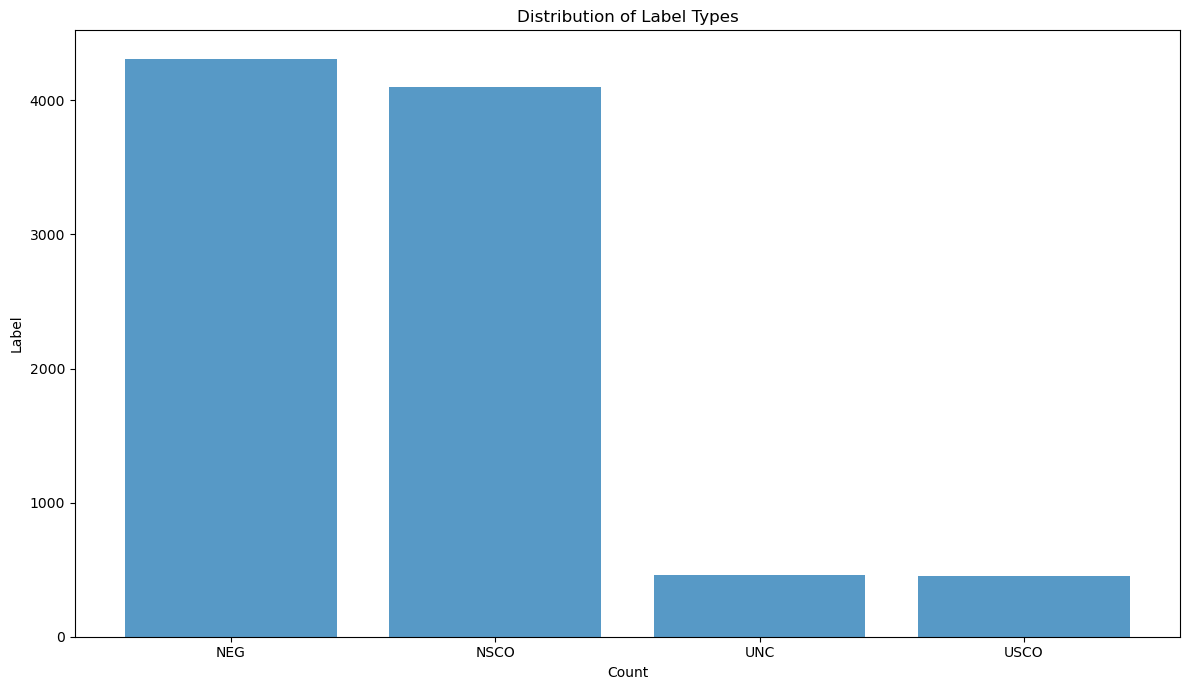

In [62]:
# Count the occurrences of each label
label_counts = df_predictions["label"].value_counts()

print("Label Distribution:")
for label, count in label_counts.items():
    print(f"{label}: {count} ({count/len(df_predictions)*100:.2f}%)")

labels = label_counts.index
counts = label_counts.values

# Plot the distribution using Matplotlib directly
plt.figure(figsize=(12, 7))
plt.bar(labels, counts, alpha=0.75)
plt.title("Distribution of Label Types")
plt.xlabel("Count")
plt.ylabel("Label")
plt.tight_layout()
plt.show()

In [64]:
# Common Negation Cues
neg_cues = df_predictions[df_predictions["label"] == "NEG"]["clean_text"].value_counts()
print("TOP Negation Cues: \n")
for cue, count in neg_cues.items():
    print(f"{cue}: {count}")

TOP Negation Cues: 

no: 1909
sin: 1424
negativo: 203
afebril: 189
niega: 136
negativos: 92
ausencia de: 64
negativa: 54
sense: 40
neg: 35
negativas: 24
asintomatica: 11
asintomatico: 10
ex: 9
descarta: 8
inespecifico: 8
falta de: 7
impide: 5
tampoco: 4
se retira: 4
nega: 4
exfumador: 4
cede: 4
ex-: 4
inespecificos: 3
negatiu: 3
retiro: 3
descartada: 3
desaparicion de: 3
negatividad de: 3
retirar: 3
inestabilidad: 3
desorientacion: 2
niegan: 2
excepto: 2
ausencia: 2
imposibilidad de: 2
incapacidad para: 2
se desestimo: 1
ex fumador: 1
suspendido: 1
ceden: 1
irregulares: 1
indetectable: 1
negaitvo: 1
negatividad: 1
imposibilidad: 1
se suspende: 1
desorientado: 1
ninguno: 1
rechaza: 1
en ninguna: 1
desaparecen: 1
arritmicos: 1
desaparicion del: 1
negatividad del: 1
atipicos: 1


In [65]:
# Common Uncertainty Cues
unc_cues = df_predictions[df_predictions["label"] == "UNC"]["clean_text"].value_counts()
print("TOP Uncertainty Cues: \n")
for cue, count in unc_cues.items():
    print(f"{cue}: {count}")

TOP Uncertainty Cues: 

compatible con: 58
probable: 54
sospecha de: 31
se orienta: 23
probablemente: 23
posible: 20
sugestiva de: 18
aparentemente: 17
compatibles con: 17
dudosa: 13
valorar: 12
sugestivo de: 10
podria: 10
sugestivos de: 9
parece: 9
sugestivas de: 7
aparente: 7
posiblemente: 5
vs: 5
dudoso: 5
sospechosa de: 4
podrian: 4
probables: 4
dudosamente: 4
sugiere: 4
no: 4
posibilidad de: 3
impresiona: 3
sospechosas de: 3
desconoce: 3
sin: 3
dudosos: 3
sugiriendo: 3
sospecha: 2
parecen: 2
sin poder descartar: 2
sugieren: 2
puede: 2
impresiona de: 2
no parece: 2
sin aparentes: 2
sin aparente: 2
orientan: 2
compatible amb: 2
aparentes: 2
sugieran: 2
ssospechosas de: 2
falsa: 1
sin claras: 1
sugestivos con: 1
desconocido: 1
pudieran: 1
orienta como: 1
se orientan: 1
plantea: 1
sin clara: 1
indiquen: 1
atribuida: 1
orienta: 1
se desconoce: 1
poco porque: 1
sugestiva como: 1
sospechosos de: 1
sospitosa de: 1
al parecer: 1
no es posible descartar: 1
interpreta: 1
sospechan de: 1
desc

Average NSCO length: 24.36 characters
Average USCO length: 30.08 characters


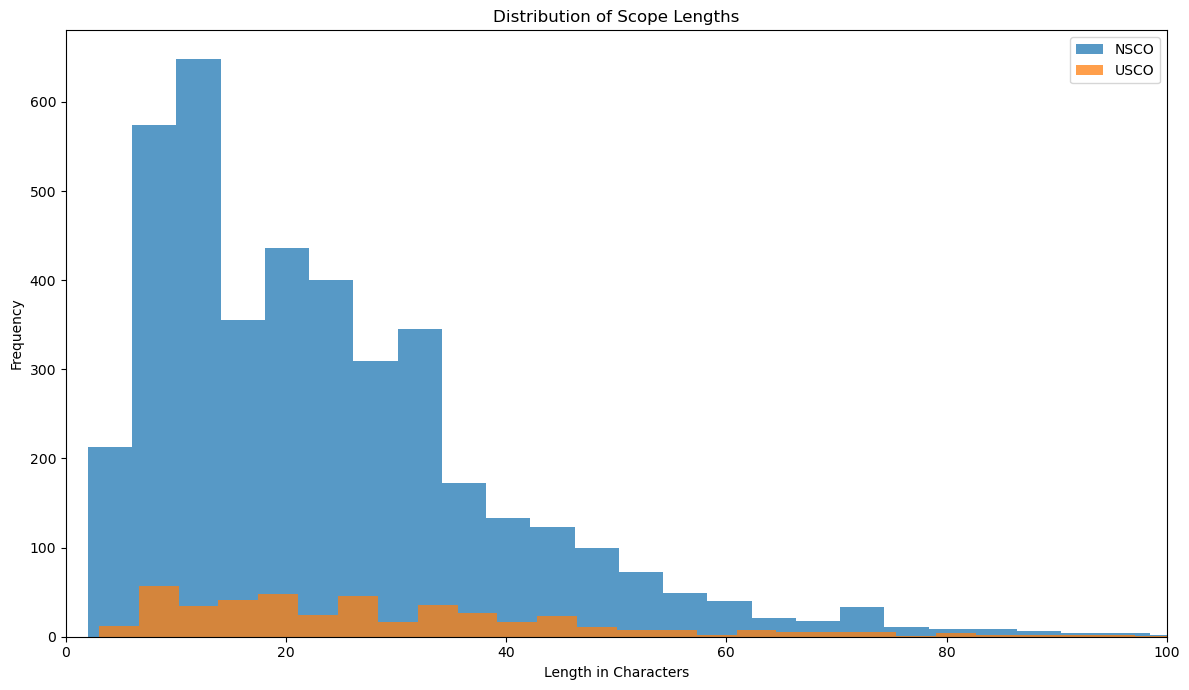

In [66]:
# Calculate scope lengths
df_predictions["text_length"] = df_predictions["text"].apply(len)

scope_labels = ["NSCO", "USCO"]

# Average Scope's 
for label in scope_labels:
    avg_len = df_predictions[df_predictions["label"] == label]["text_length"].mean()
    print(f"Average {label} length: {avg_len:.2f} characters")

# Plot scope length distributions by label type
plt.figure(figsize=(12, 7))
for label in scope_labels:
    scope_lengths = df_predictions[df_predictions["label"] == label]["text_length"]
    plt.hist(scope_lengths, bins=50, alpha=0.75, label=label)

plt.title("Distribution of Scope Lengths")
plt.xlabel("Length in Characters")
plt.ylabel("Frequency")
plt.legend()
plt.xlim(0, 100) # Limit to most common
plt.tight_layout()
plt.show()

### Create groups of Cues-Scope
We agrupate them based on distances in the text. A scope is assigned to the closest cue.

In [67]:
# create a new column to store the scope for a CUE
df_predictions["scope"] = None

for index, row in df_predictions.iterrows():
    if row["label"] == "NSCO":
        before = df_predictions.iloc[index - 1]["label"] if index > 0 else None
        after = df_predictions.iloc[index + 1]["label"] if index < len(df_predictions) - 1 else None
        if before == "NEG":
            if df_predictions.iloc[index - 1]["end"] == row["start"]:
                df_predictions.at[index, "scope"] = index - 1
        elif after == "NEG":
            if df_predictions.iloc[index + 1]["start"] == row["end"]:
                df_predictions.at[index, "scope"] = index + 1
        else:
            df_predictions.at[index, "scope"] = None

    elif row["label"] == "USCO":
        before = df_predictions.iloc[index - 1]["label"] if index > 0 else None
        after = df_predictions.iloc[index + 1]["label"] if index < len(df_predictions) - 1 else None
        if before == "UNC":
            if df_predictions.iloc[index - 1]["end"] == row["start"]:
                df_predictions.at[index, "scope"] = index - 1
        elif after == "UNC":
            if df_predictions.iloc[index + 1]["start"] == row["end"]:
                df_predictions.at[index, "scope"] = index + 1
        else:
            df_predictions.at[index, "scope"] = None

# second pass
for index, row in df_predictions.iterrows():
    if row["label"] == "NSCO":
        if row["scope"] == None:
            before = df_predictions.iloc[index - 1]["label"] if index > 0 else None
            after = df_predictions.iloc[index + 1]["label"] if index < len(df_predictions) - 1 else None

            if before == "NEG":
                df_predictions.at[index, "scope"] = index - 1
            elif after == "NEG":
                df_predictions.at[index, "scope"] = index + 1

    elif row["label"] == "USCO":
        if row["scope"] == None:
            before = df_predictions.iloc[index - 1]["label"] if index > 0 else None
            after = df_predictions.iloc[index + 1]["label"] if index < len(df_predictions) - 1 else None

            if before == "UNC":
                df_predictions.at[index, "scope"] = index - 1
            elif after == "UNC":
                df_predictions.at[index, "scope"] = index + 1